# EDA — CDR-H3 Antibody Sequence Properties

Exploratory data analysis on the smoke dataset (`data/smoke/sequences_smoke.csv`).  
Runs on Codespaces CPU with ~2,000 sequences.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

## 1. Load data

In [2]:
df = pd.read_csv('../data/smoke/sequences_smoke.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Nulls:\n{df.isnull().sum()}')
df.head()

Shape: (2000, 6)
Columns: ['sequence_id', 'heavy_chain_sequence', 'cdr_h3', 'cdr_h3_length', 'length_class', 'hydrophobicity']
Nulls:
sequence_id             0
heavy_chain_sequence    0
cdr_h3                  0
cdr_h3_length           0
length_class            0
hydrophobicity          0
dtype: int64


,sequence_id,heavy_chain_sequence,cdr_h3,cdr_h3_length,length_class,hydrophobicity
0,seq_01860,PKPHCTWWKRDVMGCCQLNNPWTVRFRIRALKVIGFMREMQLTDWM...,CKSFHLPIFDQAFRF,15,long,0.1867
1,seq_00353,AFHNITGANQVWWGDICVKTDGDVFSEYRTTGYHGIKGSDFTPVVD...,DFFCYPPL,8,short,0.4875
2,seq_01333,SHSLDKSRQYFNHHPSEVDSFTNWTPGGDTPFPTAPRPDNLAWPWP...,SHDCWNRKCE,10,medium,-1.8800
3,seq_00905,CRSVSHHTIHIKMEYMAFKEFNDREIEDMTAVSVCLCALIWRFKKY...,GLCKAQDGHAH,11,medium,-0.7455
4,seq_01289,RCPAMNCMAWEMLANSFGLCPWEVMQIHGILAHMSAIVCDEHLVVF...,AMRNWNKPVRKLNQ,14,medium,-1.5429


In [3]:
df.dtypes

sequence_id                 str
heavy_chain_sequence        str
cdr_h3                      str
cdr_h3_length             int64
length_class                str
hydrophobicity          float64
dtype: object

## 2. Length class distribution

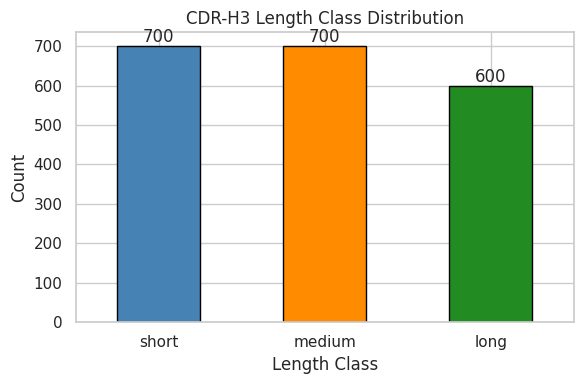

length_class
short     700
medium    700
long      600
Name: count, dtype: int64


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['length_class'].value_counts().reindex(['short', 'medium', 'long'])
counts.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange', 'forestgreen'], edgecolor='black')
ax.set(title='CDR-H3 Length Class Distribution', xlabel='Length Class', ylabel='Count')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(counts)

## 3. CDR-H3 length histogram

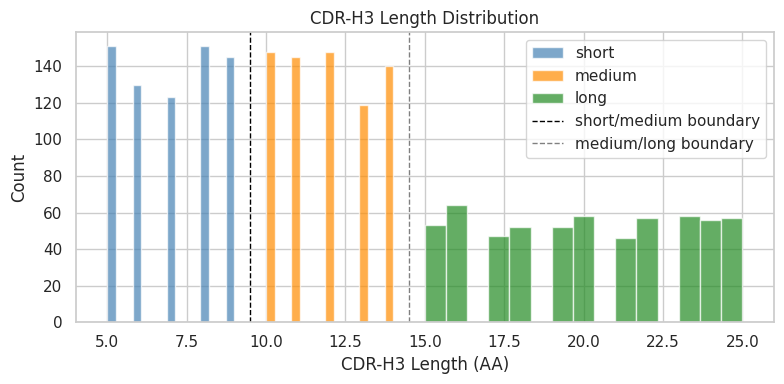

count    2000.00000
mean       12.64600
std         5.67616
min         5.00000
25%         8.00000
50%        12.00000
75%        16.00000
max        25.00000
Name: cdr_h3_length, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for cls, color in zip(['short', 'medium', 'long'], ['steelblue', 'darkorange', 'forestgreen']):
    subset = df[df['length_class'] == cls]['cdr_h3_length']
    ax.hist(subset, bins=15, alpha=0.7, label=cls, color=color, edgecolor='white')
ax.axvline(9.5, color='black', linestyle='--', linewidth=1, label='short/medium boundary')
ax.axvline(14.5, color='gray', linestyle='--', linewidth=1, label='medium/long boundary')
ax.set(title='CDR-H3 Length Distribution', xlabel='CDR-H3 Length (AA)', ylabel='Count')
ax.legend()
plt.tight_layout()
plt.show()
print(df['cdr_h3_length'].describe())

## 4. Hydrophobicity score distribution

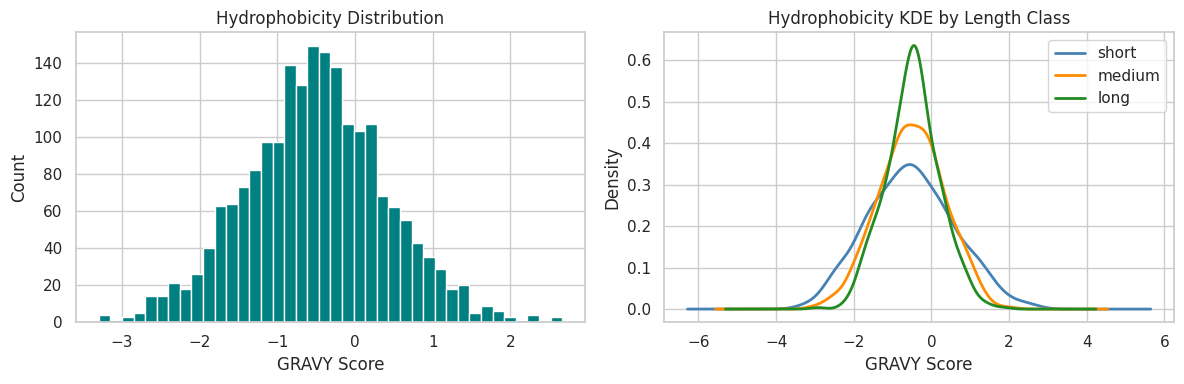

count    2000.000000
mean       -0.506380
std         0.909153
min        -3.300000
25%        -1.107850
50%        -0.510250
75%         0.081350
max         2.666700
Name: hydrophobicity, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['hydrophobicity'], bins=40, color='teal', edgecolor='white')
axes[0].set(title='Hydrophobicity Distribution', xlabel='GRAVY Score', ylabel='Count')

for cls, color in zip(['short', 'medium', 'long'], ['steelblue', 'darkorange', 'forestgreen']):
    subset = df[df['length_class'] == cls]['hydrophobicity']
    subset.plot.kde(ax=axes[1], label=cls, color=color, linewidth=2)
axes[1].set(title='Hydrophobicity KDE by Length Class', xlabel='GRAVY Score')
axes[1].legend()

plt.tight_layout()
plt.show()
print(df['hydrophobicity'].describe())

## 5. Example sequences per class

In [7]:
for cls in ['short', 'medium', 'long']:
    examples = df[df['length_class'] == cls][['cdr_h3', 'cdr_h3_length', 'hydrophobicity']].head(3)
    print(f'\n--- {cls.upper()} ---')
    print(examples.to_string(index=False))


--- SHORT ---
  cdr_h3  cdr_h3_length  hydrophobicity
DFFCYPPL              8          0.4875
SNFSRYDC              8         -1.1375
MWMSECSM              8          0.2750

--- MEDIUM ---
        cdr_h3  cdr_h3_length  hydrophobicity
    SHDCWNRKCE             10         -1.8800
   GLCKAQDGHAH             11         -0.7455
AMRNWNKPVRKLNQ             14         -1.5429

--- LONG ---
                 cdr_h3  cdr_h3_length  hydrophobicity
        CKSFHLPIFDQAFRF             15          0.1867
        VNLYDTAYPNPYYLT             15         -0.4467
YLSTKCQCTDWEYWPLNYESTCK             23         -0.9217


## 6. Amino acid frequency heatmap (position × AA)

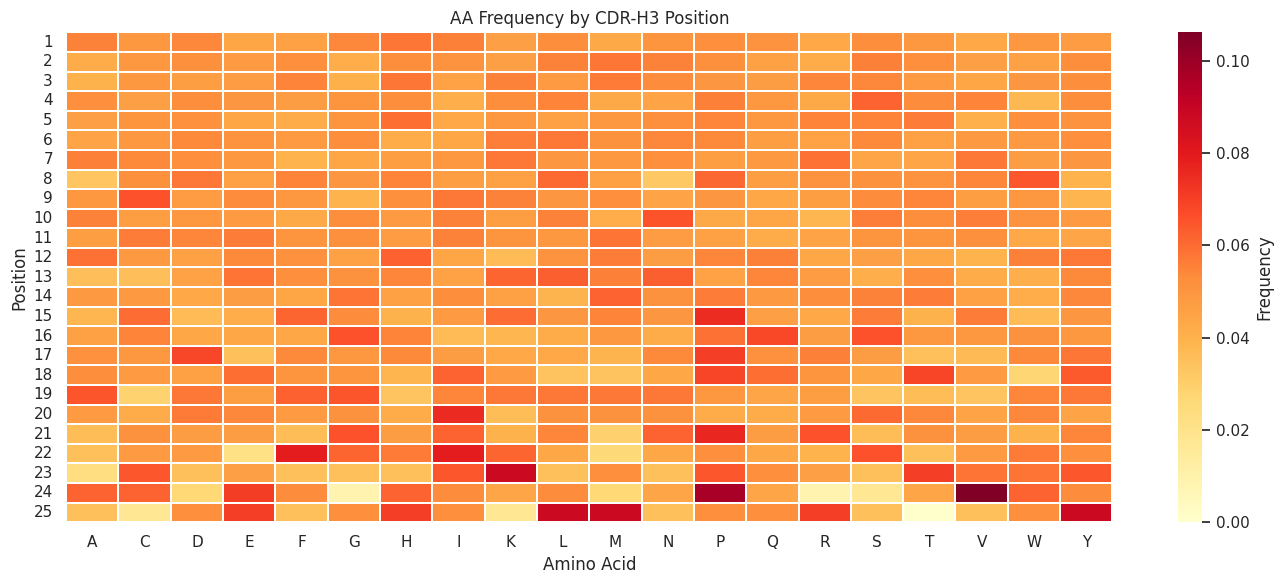

In [8]:
AA = list('ACDEFGHIKLMNPQRSTVWY')
max_pos = 25

freq = np.zeros((max_pos, len(AA)))
for seq in df['cdr_h3']:
    for pos, aa in enumerate(seq[:max_pos]):
        if aa in AA:
            freq[pos, AA.index(aa)] += 1

# Normalise per position
row_sums = freq.sum(axis=1, keepdims=True).clip(min=1)
freq_norm = freq / row_sums

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(freq_norm, ax=ax, xticklabels=AA, yticklabels=range(1, max_pos+1),
            cmap='YlOrRd', linewidths=0.3, cbar_kws={'label': 'Frequency'})
ax.set(title='AA Frequency by CDR-H3 Position', xlabel='Amino Acid', ylabel='Position')
plt.tight_layout()
plt.show()

## 7. Correlation: CDR-H3 length vs hydrophobicity

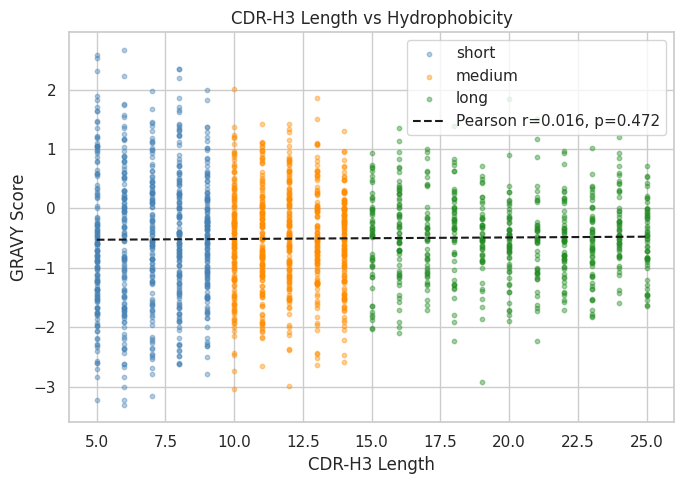

Pearson r = 0.0161, p-value = 0.4724


In [9]:
from scipy import stats

r, p = stats.pearsonr(df['cdr_h3_length'], df['hydrophobicity'])

fig, ax = plt.subplots(figsize=(7, 5))
for cls, color in zip(['short', 'medium', 'long'], ['steelblue', 'darkorange', 'forestgreen']):
    sub = df[df['length_class'] == cls]
    ax.scatter(sub['cdr_h3_length'], sub['hydrophobicity'], alpha=0.4, s=10, label=cls, color=color)

m, b = np.polyfit(df['cdr_h3_length'], df['hydrophobicity'], 1)
xs = np.array([df['cdr_h3_length'].min(), df['cdr_h3_length'].max()])
ax.plot(xs, m*xs + b, 'k--', linewidth=1.5, label=f'Pearson r={r:.3f}, p={p:.3g}')

ax.set(title='CDR-H3 Length vs Hydrophobicity', xlabel='CDR-H3 Length', ylabel='GRAVY Score')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Pearson r = {r:.4f}, p-value = {p:.4g}')